## Visualizing Depth From EXR
To run this notebook you first have to generate the `toy_dataset` which can be generated by executing `make toy_dataset`

In [1]:
import OpenEXR
import numpy as np
import Imath
import array
import cv2
import matplotlib.pyplot as plt
import json

### EXR to numpy array
Thanks to [Tobias Weis](http://www.tobias-weis.de/groundtruth-data-for-computer-vision-with-blender/)

In [2]:
def exr2numpy(exr, maxvalue=None, normalize=True):
    """Load Blender's depth pass into a 2D array."""
    file = OpenEXR.InputFile(exr)

    # Compute the size
    dw = file.header()['dataWindow']
    sz = (dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1)

    # Blender 5 prefixes compositor EXR channels with the output item name.
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    channels = file.header()['channels']
    red_channel = next(channel for channel in channels if channel.endswith('.R'))
    data = np.asarray(array.array('f', file.channel(red_channel, FLOAT)))
    depth = data.reshape(sz[1], sz[0])

    # Blender uses 1e10 for pixels that do not intersect scene geometry.
    depth = np.where(depth >= 1e9, np.nan, depth)
    if maxvalue is not None:
        depth = np.minimum(depth, maxvalue)

    if normalize:
        minimum = np.nanmin(depth)
        maximum = np.nanmax(depth)
        if maximum > minimum:
            depth = (depth - minimum) / (maximum - minimum)

    return depth

### Read the color image

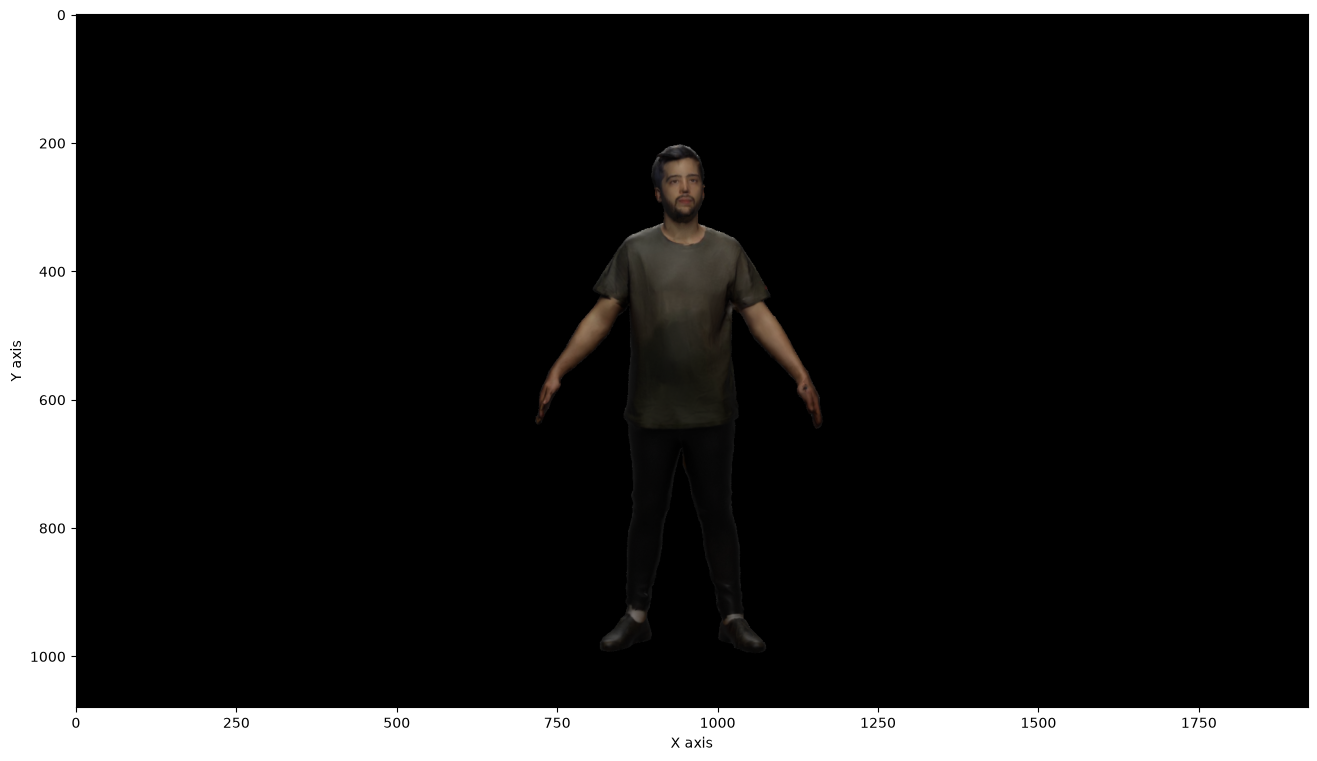

In [3]:
# The frame of the dataset we will use for visualization
FRAME_NUM = 5

# Create the figure
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Plot the color image
color = cv2.cvtColor(cv2.imread('../data/toy_dataset/color/Image{:0>4}.png'.format(FRAME_NUM)), cv2.COLOR_BGR2RGB)
ax.imshow(color)
plt.show()

### Read the depth EXR file
Depth values are in meters but in order to visualize them we normalize the range 0-5 meters

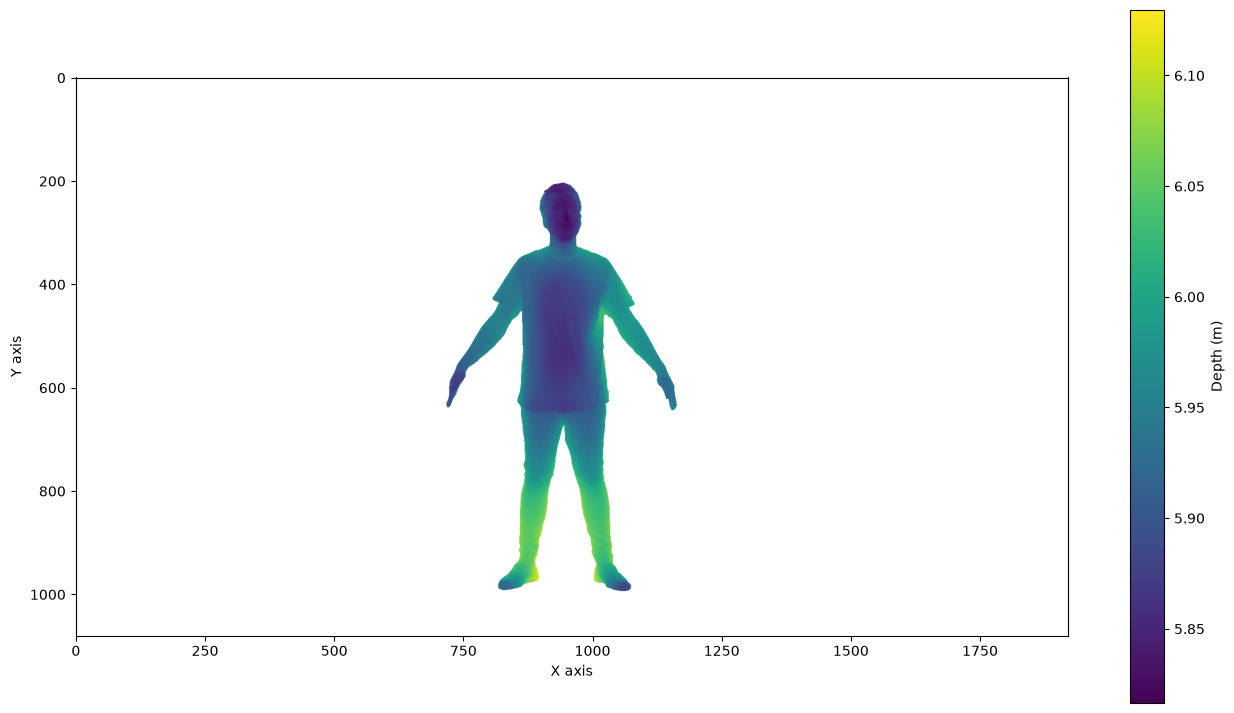

In [4]:
# Create the figure
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Draw the depth
depth_data = exr2numpy('../data/toy_dataset/depth/Image{:0>4}.exr'.format(FRAME_NUM), normalize=False)
image = ax.imshow(depth_data, cmap='viridis')
fig.colorbar(image, ax=ax, label='Depth (m)')
plt.show()